# Global registration with RANSAC
We are going to use [open3d](http://www.open3d.org/) to handle point clouds and generation of point clouds
We are importing the packages and defining a function which helps us drawing the point clouds.

In [1]:
import os
import open3d as o3d
import numpy as np
import copy
import matplotlib.pyplot as plt

os.environ["XDG_SESSION_TYPE"] = "x11"
# Visualize two point clouds (orange=source, blue=target)
def draw_registrations(source, target, transformation=None, recolor=False):
    source_temp = copy.deepcopy(source)
    target_temp = copy.deepcopy(target)

    if recolor:
        source_temp.paint_uniform_color([1, 0.706, 0])  # Orange
        target_temp.paint_uniform_color([0, 0.651, 0.929])  # Blue

    if transformation is not None:
        source_temp.transform(transformation)  # Apply transformation to source

    o3d.visualization.draw_geometries([source_temp, target_temp])

# Show before/after alignment from top view (2D)
def visualize_point_clouds_2d(source, target, transformation=None, title="Point Clouds"):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    source_pts = np.asarray(source.points)
    target_pts = np.asarray(target.points)

    # Left plot: BEFORE alignment
    axes[0].scatter(source_pts[::10, 0], source_pts[::10, 1], c='orange', s=1, alpha=0.5, label='Source')
    axes[0].scatter(target_pts[::10, 0], target_pts[::10, 1], c='blue', s=1, alpha=0.5, label='Target')
    axes[0].set_title('Before Alignment')
    axes[0].legend()
    axes[0].axis('equal')

    # Right plot: AFTER alignment
    if transformation is not None:
        source_transformed = copy.deepcopy(source)
        source_transformed.transform(transformation)
        source_pts_t = np.asarray(source_transformed.points)
        axes[1].scatter(source_pts_t[::10, 0], source_pts_t[::10, 1], c='orange', s=1, alpha=0.5, label='Source')
        axes[1].scatter(target_pts[::10, 0], target_pts[::10, 1], c='blue', s=1, alpha=0.5, label='Target')
        axes[1].set_title('After Alignment')
    else:
        axes[1].scatter(source_pts[::10, 0], source_pts[::10, 1], c='orange', s=1, alpha=0.5, label='Source')
        axes[1].scatter(target_pts[::10, 0], target_pts[::10, 1], c='blue', s=1, alpha=0.5, label='Target')
        axes[1].set_title('No Transformation')

    axes[1].legend()
    axes[1].axis('equal')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Show which points match between source and target (green lines)
def visualize_correspondences(source, target, source_fpfh, target_fpfh, max_distance=0.5):
    from sklearn.neighbors import NearestNeighbors

    # Extract feature descriptors
    source_features = np.array(source_fpfh.data).T
    target_features = np.array(target_fpfh.data).T

    # Find nearest neighbor in target for each source point
    nbrs = NearestNeighbors(n_neighbors=1).fit(target_features)
    distances, indices = nbrs.kneighbors(source_features)

    # Keep only good matches (below distance threshold)
    valid_matches = distances[:, 0] < max_distance

    source_pts = np.asarray(source.points)
    target_pts = np.asarray(target.points)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Left: Show correspondences (green lines connecting matched points)
    ax1.scatter(source_pts[::10, 0], source_pts[::10, 1], c='orange', s=5, alpha=0.3, label='Source')
    ax1.scatter(target_pts[::10, 0], target_pts[::10, 1], c='blue', s=5, alpha=0.3, label='Target')

    # Draw 50 random correspondence lines
    num_lines = min(50, np.sum(valid_matches))
    valid_indices = np.where(valid_matches)[0]
    selected = np.random.choice(valid_indices, num_lines, replace=False)

    for idx in selected:
        target_idx = indices[idx, 0]
        ax1.plot([source_pts[idx, 0], target_pts[target_idx, 0]],
                [source_pts[idx, 1], target_pts[target_idx, 1]],
                'g-', alpha=0.3, linewidth=0.5)

    ax1.set_title(f'Correspondences ({num_lines} of {np.sum(valid_matches)} shown)')
    ax1.legend()
    ax1.axis('equal')

    # Right: Histogram of match quality
    ax2.hist(distances[valid_matches], bins=50, alpha=0.7)
    ax2.axvline(max_distance, color='r', linestyle='--', label='Threshold')
    ax2.set_xlabel('Feature Distance')
    ax2.set_ylabel('Count')
    ax2.set_title('Match Quality Distribution')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    print(f"Found {np.sum(valid_matches)} correspondences out of {len(source_pts)} points")

# Show RANSAC quality: Fitness (% aligned), RMSE (error), and Transformation Matrix
def visualize_ransac_metrics(ransac_result, title="RANSAC Result"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Left: Fitness score (higher is better, 0-1 range)
    axes[0].bar(['Fitness'], [ransac_result.fitness], color='green', alpha=0.7)
    axes[0].set_title('Fitness (% points aligned)')
    axes[0].set_ylim([0, 1])
    axes[0].text(0, ransac_result.fitness + 0.05, f'{ransac_result.fitness:.4f}', ha='center')

    # Middle: RMSE (lower is better)
    axes[1].bar(['RMSE'], [ransac_result.inlier_rmse], color='orange', alpha=0.7)
    axes[1].set_title('Inlier RMSE (error)')
    axes[1].text(0, ransac_result.inlier_rmse * 1.05, f'{ransac_result.inlier_rmse:.4f}', ha='center')

    # Right: Transformation matrix (rotation + translation)
    transform = ransac_result.transformation
    im = axes[2].imshow(transform, cmap='RdBu', aspect='auto')
    axes[2].set_title('Transformation Matrix')

    # Add matrix values as text
    for i in range(4):
        for j in range(4):
            axes[2].text(j, i, f'{transform[i, j]:.3f}', ha="center", va="center", fontsize=8)

    plt.colorbar(im, ax=axes[2])
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


We need to read in our pointclouds. For that we use the `io` module of the
open3d package (`o3d`). The following cell will open a window with a
visualization of both point clouds `source` and `target`.

Also, this page [Visualization - Open3D](http://open3d.org/html/tutorial/Basic/visualization.html)
contains some useful examples and instructions on how to use the viewer.

In [2]:
source = o3d.io.read_point_cloud("ICP/r1.pcd")
target = o3d.io.read_point_cloud("ICP/r2.pcd")

# Used for downsampling.
voxel_size = 0.05

# Show models side by side
draw_registrations(source, target)

### Finding features in pointclouds
When working on point clouds it can be beneficial to work on a downsampled version of the point cloud,
as it decreases the need of computation.

You can use [`pointcloud.voxel_down_sample()`](http://www.open3d.org/docs/latest/python_api/open3d.geometry.PointCloud.html#open3d.geometry.PointCloud.voxel_down_sample) where `pointcloud` is the name of your point cloud object. In our case, that would be `source` and `target`.

We also need to estimate the normals of the point cloud points using [`pointcloud.estimate_normals()`](http://www.open3d.org/docs/latest/python_api/open3d.geometry.PointCloud.html#open3d.geometry.PointCloud.voxel_down_sample)

**Task:** Find FPFH features or correspondances of the downsampled point clouds.
[`o3d.pipelines.registration.compute_fpfh_feature()`](http://www.open3d.org/docs/latest/python_api/open3d.pipelines.registration.compute_fpfh_feature.html)


In [3]:
# Downsample the point clouds
source_sample = source.voxel_down_sample(voxel_size)
target_sample = target.voxel_down_sample(voxel_size)

# Estimate normals
source_sample.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=voxel_size * 2, max_nn=30))
target_sample.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=voxel_size * 2, max_nn=30))

# Compute FPFH features
source_fpfh = o3d.pipelines.registration.compute_fpfh_feature(
    source_sample,
    o3d.geometry.KDTreeSearchParamHybrid(radius=voxel_size * 5, max_nn=100)
)
target_fpfh = o3d.pipelines.registration.compute_fpfh_feature(
    target_sample,
    o3d.geometry.KDTreeSearchParamHybrid(radius=voxel_size * 5, max_nn=100)
)

### RANSAC 
We will now attempt to use RANSAC to do a global registration of the two point clouds.

By using the function [`o3d.pipelines.registration.registration_ransac_based_on_feature_matching`](http://www.open3d.org/docs/latest/python_api/open3d.pipelines.registration.registration_ransac_based_on_feature_matching.html) from open3d, do the following:


Try to find the transformation from `r1.pcd` (`source`) to `r2.pcd` (`target`).
Attempt with point-to-point and point-to-plane
```Python
point_to_point =  o3d.pipelines.registration.TransformationEstimationPointToPoint(False)
point_to_plane =  o3d.pipelines.registration.TransformationEstimationPointToPlane()
```

When using RANSAC, focus on the arguments below. The rest are optional parameters.
```Python
ransac_result = o3d.registration.registration_ransac_based_on_feature_matching(
    source_sample, target_sample, 
    source_fpfh, target_fpfh, 
    distance_threshold,
    point_to_point)
```


=== Feature Correspondences (before RANSAC) ===


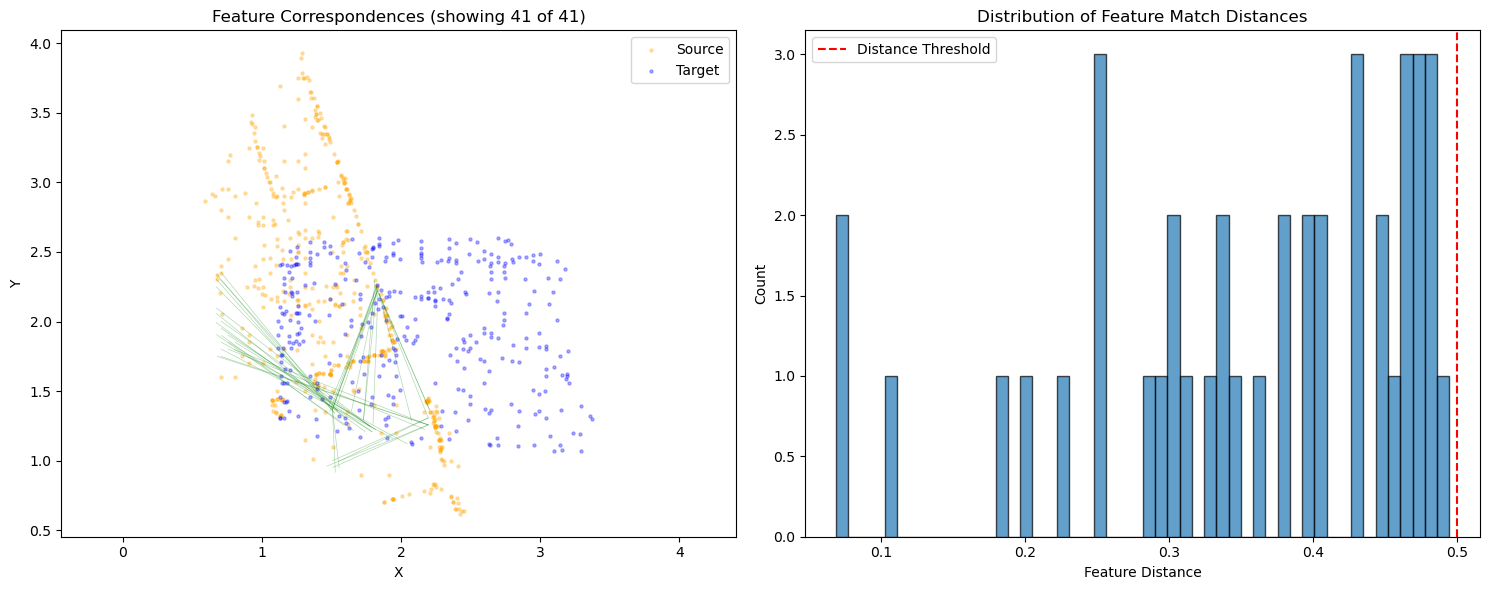

Total correspondences found: 41 out of 4760 source points

=== Running RANSAC with point-to-point ===
Fitness: 0.6810924369747899
Inlier RMSE: 0.03467942033472277
Transformation:
[[-0.52197068  0.85246951  0.02902331  0.56227956]
 [-0.22176636 -0.16848753  0.96043305  0.84070355]
 [ 0.82362995  0.49488149  0.27699461 -1.45629979]
 [ 0.          0.          0.          1.        ]]

=== RANSAC Results ===


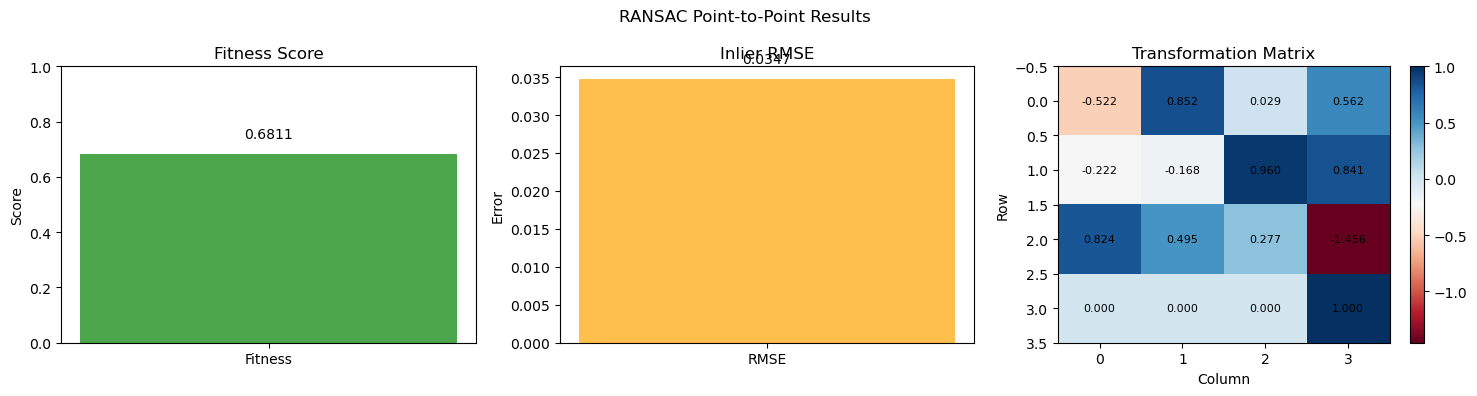

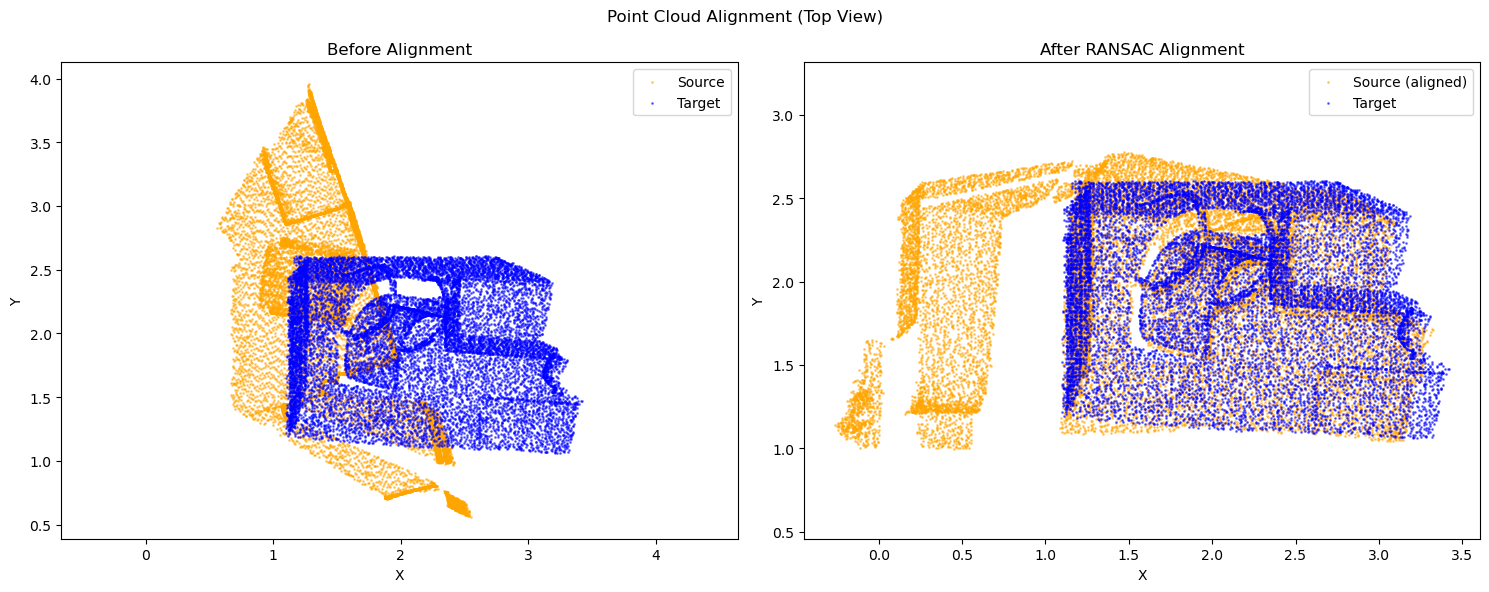

In [4]:
# Step 3: Run RANSAC to find transformation
distance_threshold = voxel_size * 1.5

# Show which features match before RANSAC
print("=== Feature Correspondences ===")
visualize_correspondences(source_sample, target_sample, source_fpfh, target_fpfh, 0.5)

# Run RANSAC (randomly samples points to find best transformation)
print("\n=== Running RANSAC ===")
ransac_result = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
    source_sample, target_sample,  # Point clouds
    source_fpfh, target_fpfh,      # Features
    True,                          # Mutual filter (both directions)
    distance_threshold,            # Max distance for inliers
    o3d.pipelines.registration.TransformationEstimationPointToPoint(False),  # Method
    3,                             # Number of points to sample
    [o3d.pipelines.registration.CorrespondenceCheckerBasedOnEdgeLength(0.9),
     o3d.pipelines.registration.CorrespondenceCheckerBasedOnDistance(distance_threshold)],
    o3d.pipelines.registration.RANSACConvergenceCriteria(4000000, 500)
)

print(f"Fitness: {ransac_result.fitness:.4f}")
print(f"RMSE: {ransac_result.inlier_rmse:.4f}")

# Visualize results
visualize_ransac_metrics(ransac_result, "RANSAC Results")
visualize_point_clouds_2d(source, target, ransac_result.transformation, "Before/After Alignment")
draw_registrations(source, target, ransac_result.transformation, True)

## Exercises
### A)
Can you get a decent transformation from r1 to r3? (check the ICP folder)

Exercise A: Registering r1 to r3...

=== Feature Correspondences (r1 to r3) ===


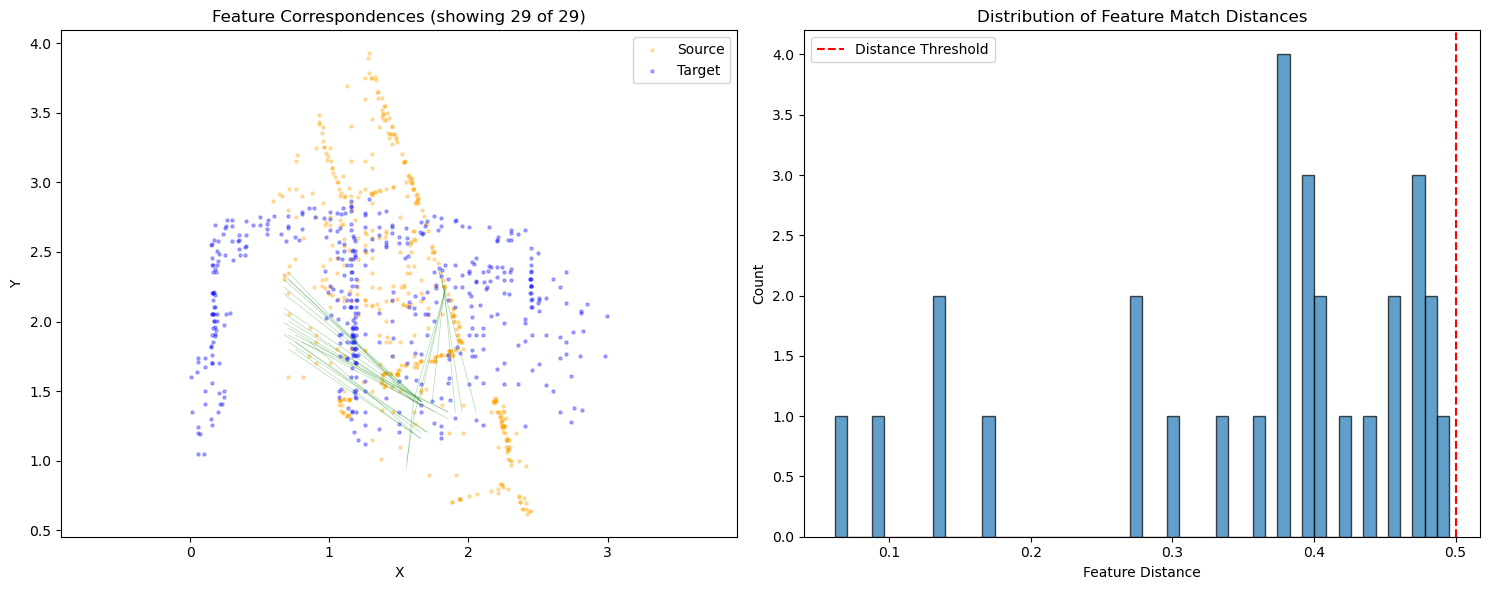

Total correspondences found: 29 out of 4760 source points
Fitness: 0.7831932773109244
Inlier RMSE: 0.039440348896655646

=== RANSAC Results (r1 to r3) ===


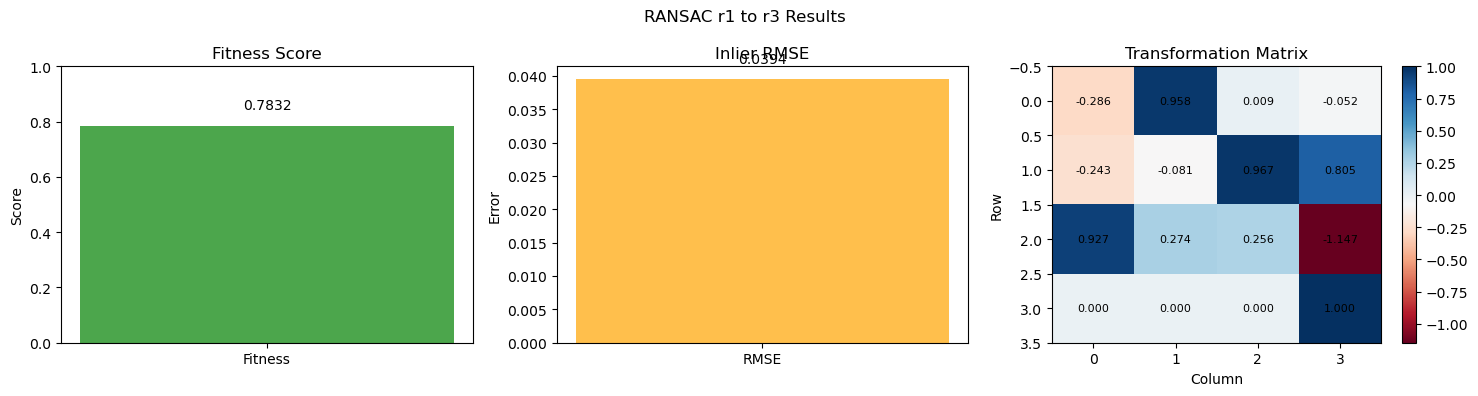

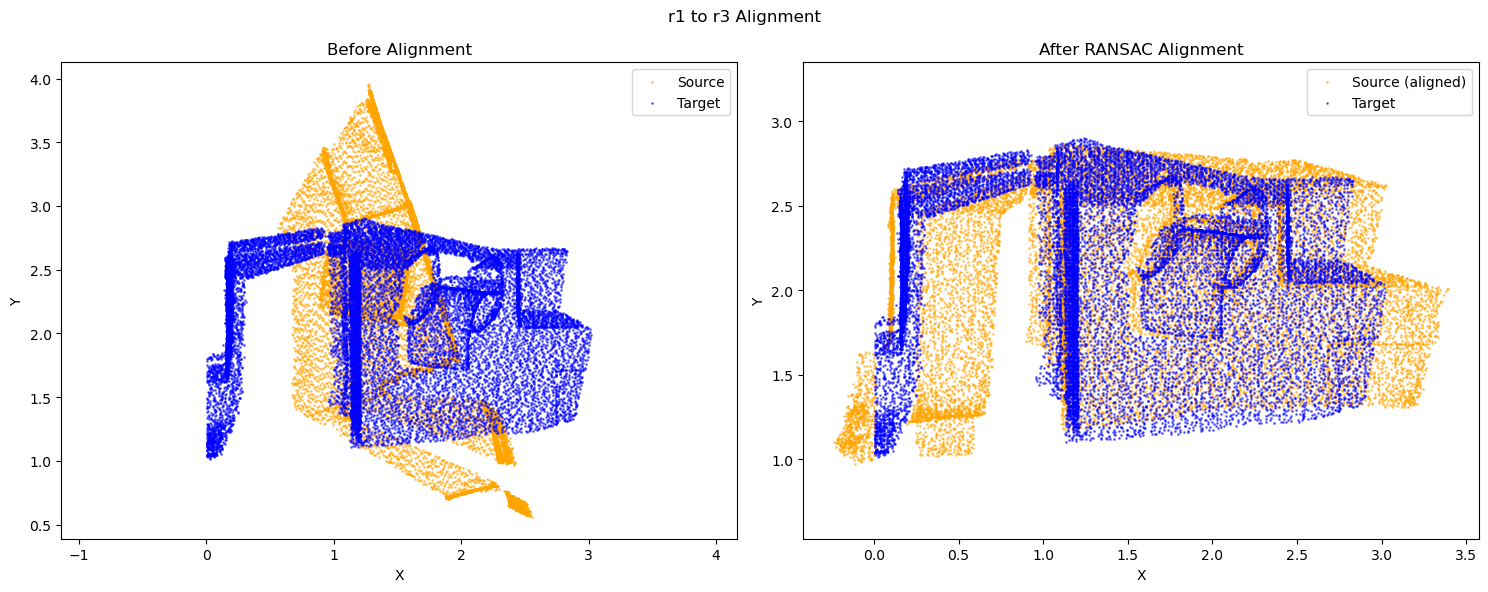

In [5]:
# Exercise A: Register r1 to r3 (same process as r1 to r2)
print("=== Exercise A: r1 to r3 ===")

# Load point clouds
source_r1 = o3d.io.read_point_cloud("ICP/r1.pcd")
target_r3 = o3d.io.read_point_cloud("ICP/r3.pcd")

# Step 1: Downsample
source_r1_sample = source_r1.voxel_down_sample(voxel_size)
target_r3_sample = target_r3.voxel_down_sample(voxel_size)

# Step 2: Estimate normals and compute features
source_r1_sample.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=voxel_size * 2, max_nn=30))
target_r3_sample.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=voxel_size * 2, max_nn=30))

source_r1_fpfh = o3d.pipelines.registration.compute_fpfh_feature(
    source_r1_sample, o3d.geometry.KDTreeSearchParamHybrid(radius=voxel_size * 5, max_nn=100))
target_r3_fpfh = o3d.pipelines.registration.compute_fpfh_feature(
    target_r3_sample, o3d.geometry.KDTreeSearchParamHybrid(radius=voxel_size * 5, max_nn=100))

# Visualize correspondences
visualize_correspondences(source_r1_sample, target_r3_sample, source_r1_fpfh, target_r3_fpfh, 0.5)

# Step 3: Run RANSAC
ransac_result_r3 = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
    source_r1_sample, target_r3_sample,
    source_r1_fpfh, target_r3_fpfh,
    True,
    voxel_size * 1.5,
    o3d.pipelines.registration.TransformationEstimationPointToPoint(False),
    3,
    [o3d.pipelines.registration.CorrespondenceCheckerBasedOnEdgeLength(0.9),
     o3d.pipelines.registration.CorrespondenceCheckerBasedOnDistance(voxel_size * 1.5)],
    o3d.pipelines.registration.RANSACConvergenceCriteria(4000000, 500)
)

print(f"Fitness: {ransac_result_r3.fitness:.4f}, RMSE: {ransac_result_r3.inlier_rmse:.4f}")

# Visualize results
visualize_ransac_metrics(ransac_result_r3, "Exercise A: r1 to r3")
visualize_point_clouds_2d(source_r1, target_r3, ransac_result_r3.transformation, "r1 to r3 Alignment")
draw_registrations(source_r1, target_r3, ransac_result_r3.transformation, True)

### B)
With the following checkers, can you get better results from RANSAC? Try tweaking the parameters of them. Can you make point-to-plane work? Do not spend too much time on this, if you can't manage, skip it. (I was not able to get a good fit.)

You can also try tweaking the `voxel_size`

```Python
corr_length = 0.9
distance_threshold = voxel_size * 1.5

c0 = o3d.pipelines.registration.CorrespondenceCheckerBasedOnEdgeLength(corr_length)
c1 = o3d.pipelines.registration.CorrespondenceCheckerBasedOnDistance(distance_threshold)
c2 = o3d.pipelines.registration.CorrespondenceCheckerBasedOnNormal(0.095)

checker_list = [c0,c1,c2]

ransac_result = o3d.registration.registration_ransac_based_on_feature_matching(
    source_sample, target_sample, 
    source_fpfh, target_fpfh, 
    True,
    distance_threshold,
    point_to_point,
    checkers = checker_list)
```

Exercise B: Testing with different checkers...

Testing with point-to-point and custom checkers...
Point-to-Point - Fitness: 0.6636247198206853, Inlier RMSE: 0.022626326267270035


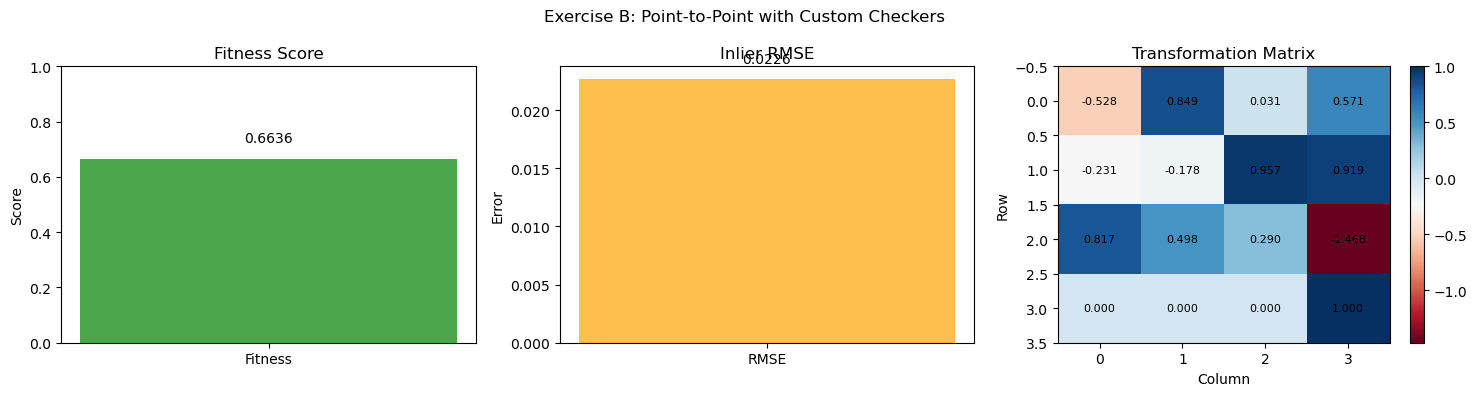


Testing with point-to-plane and custom checkers...
Point-to-Plane - Fitness: 0.0, Inlier RMSE: 0.0


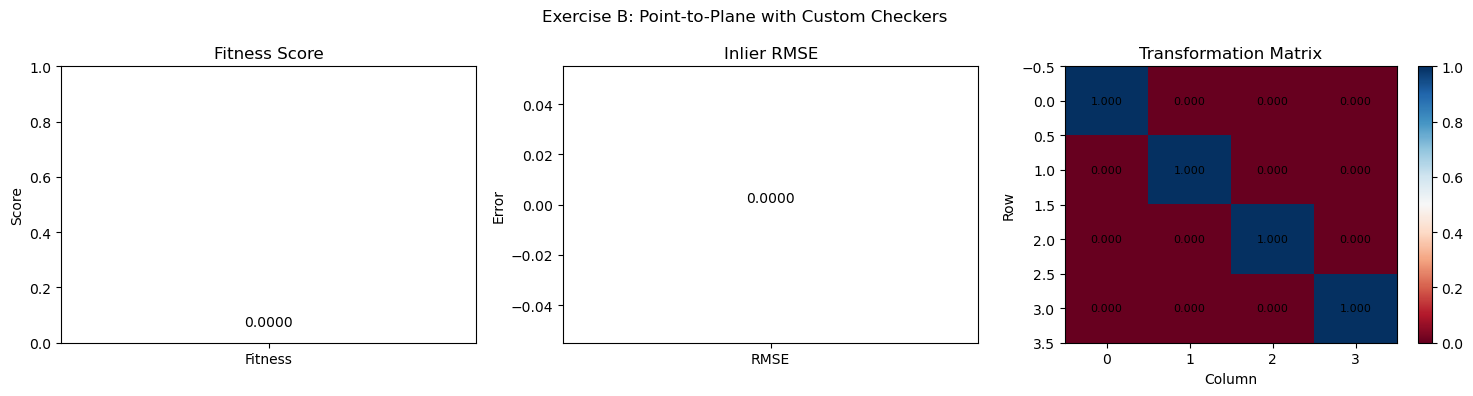

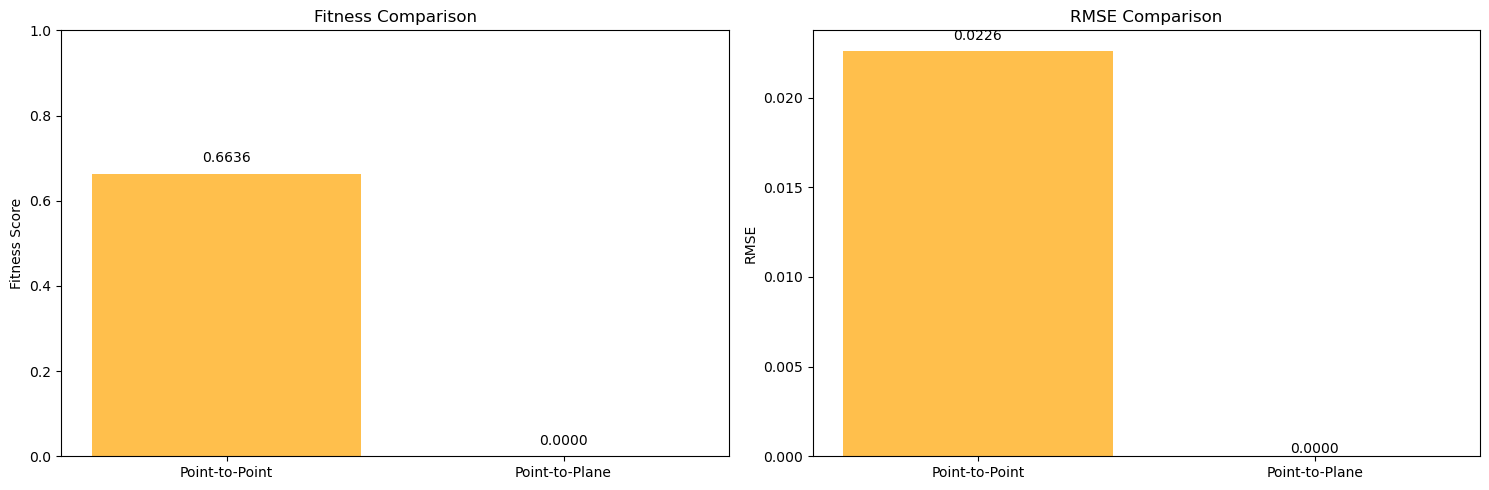


Point-to-Point performed better!


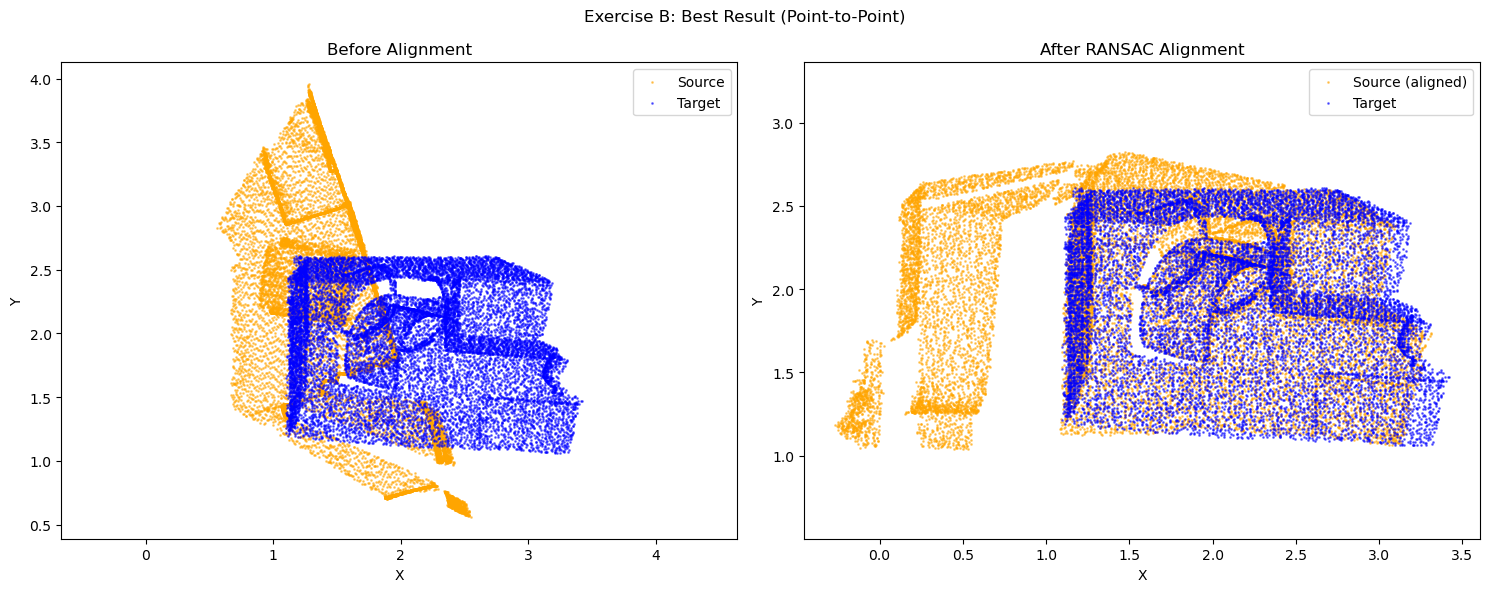

In [6]:
# Exercise B: Test custom checkers and Point-to-Point vs Point-to-Plane
print("=== Exercise B: Comparing Methods ===")

# Use finer voxel size for better detail
voxel_size_fine = 0.03

# Prepare data (same steps as before)
source_fine = source.voxel_down_sample(voxel_size_fine)
target_fine = target.voxel_down_sample(voxel_size_fine)

source_fine.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=voxel_size_fine * 2, max_nn=30))
target_fine.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=voxel_size_fine * 2, max_nn=30))

source_fpfh_fine = o3d.pipelines.registration.compute_fpfh_feature(
    source_fine, o3d.geometry.KDTreeSearchParamHybrid(radius=voxel_size_fine * 5, max_nn=100))
target_fpfh_fine = o3d.pipelines.registration.compute_fpfh_feature(
    target_fine, o3d.geometry.KDTreeSearchParamHybrid(radius=voxel_size_fine * 5, max_nn=100))

# Custom checkers (filters for correspondence quality)
distance_threshold_b = voxel_size_fine * 2.0
checkers = [
    o3d.pipelines.registration.CorrespondenceCheckerBasedOnEdgeLength(0.85),  # Edge length check
    o3d.pipelines.registration.CorrespondenceCheckerBasedOnDistance(distance_threshold_b),  # Distance check
    o3d.pipelines.registration.CorrespondenceCheckerBasedOnNormal(0.1)  # Normal angle check
]

# Test 1: Point-to-Point
print("\n1. Point-to-Point...")
ransac_p2p = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
    source_fine, target_fine, source_fpfh_fine, target_fpfh_fine,
    True, distance_threshold_b,
    o3d.pipelines.registration.TransformationEstimationPointToPoint(False),
    3, checkers, o3d.pipelines.registration.RANSACConvergenceCriteria(4000000, 500)
)
print(f"   Fitness: {ransac_p2p.fitness:.4f}, RMSE: {ransac_p2p.inlier_rmse:.4f}")

# Test 2: Point-to-Plane
print("\n2. Point-to-Plane...")
ransac_p2pl = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
    source_fine, target_fine, source_fpfh_fine, target_fpfh_fine,
    True, distance_threshold_b,
    o3d.pipelines.registration.TransformationEstimationPointToPlane(),
    3, checkers, o3d.pipelines.registration.RANSACConvergenceCriteria(4000000, 500)
)
print(f"   Fitness: {ransac_p2pl.fitness:.4f}, RMSE: {ransac_p2pl.inlier_rmse:.4f}")

# Compare results visually
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
methods = ['Point-to-Point', 'Point-to-Plane']

# Compare fitness
axes[0].bar(methods, [ransac_p2p.fitness, ransac_p2pl.fitness], color=['orange', 'blue'], alpha=0.7)
axes[0].set_ylabel('Fitness')
axes[0].set_title('Fitness Comparison')
axes[0].set_ylim([0, 1])

# Compare RMSE
axes[1].bar(methods, [ransac_p2p.inlier_rmse, ransac_p2pl.inlier_rmse], color=['orange', 'blue'], alpha=0.7)
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE Comparison')

plt.tight_layout()
plt.show()

# Show the better result
if ransac_p2pl.fitness > ransac_p2p.fitness:
    print("\n✓ Point-to-Plane is better!")
    visualize_ransac_metrics(ransac_p2pl, "Best: Point-to-Plane")
    draw_registrations(source, target, ransac_p2pl.transformation, True)
else:
    print("\n✓ Point-to-Point is better!")
    visualize_ransac_metrics(ransac_p2p, "Best: Point-to-Point")
    draw_registrations(source, target, ransac_p2p.transformation, True)
